# <img style="float: left; padding-right: 10px; width: 250px" src="https://extension.harvard.edu/wp-content/uploads/sites/8/2020/08/image-10.png"> 
### Data Science Capstone Project
### NASA + Smithsonian Team Blue


## **Spring 2026**<br/>

<hr style="height:2pt">

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
from pathlib import Path

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## (a)	Import merged AGB/EO data 


In [4]:
# ============================================================
# 1. Load Data
# ============================================================
file_path = "C:/Users/svazq/HES/Capstone/Merged_Data/AGB_EO_EMIT.csv"   

df = pd.read_csv(file_path)

print(df.head())

  dataset      plot_id                 start_date                   end_date  \
0  Belige  Big Creek_1  2021-01-01 00:00:00+00:00  2021-12-01 00:00:00+00:00   
1  Belige  Big Creek_1  2021-01-01 00:00:00+00:00  2021-12-01 00:00:00+00:00   
2  Belige  Big Creek_1  2021-01-01 00:00:00+00:00  2021-12-01 00:00:00+00:00   
3  Belige  Big Creek_1  2021-01-01 00:00:00+00:00  2021-12-01 00:00:00+00:00   
4  Belige  Big Creek_1  2021-01-01 00:00:00+00:00  2021-12-01 00:00:00+00:00   

               capture_start                capture_end  \
0  2023-01-01 00:00:00+00:00  2025-12-31 00:00:00+00:00   
1  2023-01-01 00:00:00+00:00  2025-12-31 00:00:00+00:00   
2  2023-01-01 00:00:00+00:00  2025-12-31 00:00:00+00:00   
3  2023-01-01 00:00:00+00:00  2025-12-31 00:00:00+00:00   
4  2023-01-01 00:00:00+00:00  2025-12-31 00:00:00+00:00   

          EMIT_selected_date                                     EMIT_granule  \
0  2024-07-20 20:44:04+00:00  EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc   
1 

In [5]:
print("Shape:", df.shape)
df.head()

Shape: (3880, 314)


,dataset,plot_id,start_date,end_date,capture_start,capture_end,EMIT_selected_date,EMIT_granule,latitude,longitude,diameter,height,species,plant_AGB_kg,NDVI,NDRE1,NDRE2,NDRE3,NBR,MSI,EVI,CIrededge,EMIT_R381,EMIT_R388,EMIT_R396,EMIT_R403,EMIT_R411,EMIT_R418,EMIT_R425,EMIT_R433,EMIT_R440,EMIT_R448,EMIT_R455,EMIT_R463,EMIT_R470,EMIT_R477,EMIT_R485,EMIT_R492,EMIT_R500,EMIT_R507,EMIT_R515,EMIT_R522,EMIT_R530,EMIT_R537,EMIT_R544,EMIT_R552,EMIT_R559,EMIT_R567,EMIT_R574,EMIT_R582,EMIT_R589,EMIT_R597,EMIT_R604,EMIT_R611,EMIT_R619,EMIT_R626,EMIT_R634,EMIT_R641,EMIT_R649,EMIT_R656,EMIT_R664,EMIT_R671,EMIT_R679,EMIT_R686,EMIT_R693,EMIT_R701,EMIT_R708,EMIT_R716,EMIT_R723,EMIT_R731,EMIT_R738,EMIT_R746,EMIT_R753,EMIT_R761,EMIT_R768,EMIT_R776,EMIT_R783,EMIT_R790,EMIT_R798,EMIT_R805,EMIT_R813,EMIT_R820,EMIT_R828,EMIT_R835,EMIT_R843,EMIT_R850,EMIT_R858,EMIT_R865,EMIT_R873,EMIT_R880,EMIT_R887,EMIT_R895,EMIT_R902,EMIT_R910,EMIT_R917,EMIT_R925,EMIT_R932,EMIT_R940,EMIT_R947,EMIT_R955,EMIT_R962,EMIT_R970,EMIT_R977,EMIT_R984,EMIT_R992,EMIT_R999,EMIT_R1007,EMIT_R1014,EMIT_R1022,EMIT_R1029,EMIT_R1037,EMIT_R1044,EMIT_R1052,EMIT_R1059,EMIT_R1067,EMIT_R1074,EMIT_R1081,EMIT_R1089,EMIT_R1096,EMIT_R1104,EMIT_R1111,EMIT_R1119,EMIT_R1126,EMIT_R1134,EMIT_R1141,EMIT_R1149,EMIT_R1156,EMIT_R1163,EMIT_R1171,EMIT_R1178,EMIT_R1186,EMIT_R1193,EMIT_R1201,EMIT_R1208,EMIT_R1216,EMIT_R1223,EMIT_R1231,EMIT_R1238,EMIT_R1246,EMIT_R1253,EMIT_R1260,EMIT_R1268,EMIT_R1275,EMIT_R1283,EMIT_R1290,EMIT_R1298,EMIT_R1305,EMIT_R1313,EMIT_R1320,EMIT_R1439,EMIT_R1447,EMIT_R1454,EMIT_R1462,EMIT_R1469,EMIT_R1477,EMIT_R1484,EMIT_R1491,EMIT_R1499,EMIT_R1506,EMIT_R1514,EMIT_R1521,EMIT_R1529,EMIT_R1536,EMIT_R1544,EMIT_R1551,EMIT_R1558,EMIT_R1566,EMIT_R1573,EMIT_R1581,EMIT_R1588,EMIT_R1596,EMIT_R1603,EMIT_R1611,EMIT_R1618,EMIT_R1625,EMIT_R1633,EMIT_R1640,EMIT_R1648,EMIT_R1655,EMIT_R1663,EMIT_R1670,EMIT_R1677,EMIT_R1685,EMIT_R1692,EMIT_R1700,EMIT_R1707,EMIT_R1715,EMIT_R1722,EMIT_R1730,EMIT_R1737,EMIT_R1744,EMIT_R1752,EMIT_R1759,EMIT_R1767,EMIT_R1967,EMIT_R1975,EMIT_R1982,EMIT_R1990,EMIT_R1997,EMIT_R2004,EMIT_R2012,EMIT_R2019,EMIT_R2027,EMIT_R2034,EMIT_R2041,EMIT_R2049,EMIT_R2056,EMIT_R2064,EMIT_R2071,EMIT_R2079,EMIT_R2086,EMIT_R2093,EMIT_R2101,EMIT_R2108,EMIT_R2116,EMIT_R2123,EMIT_R2130,EMIT_R2138,EMIT_R2145,EMIT_R2153,EMIT_R2160,EMIT_R2167,EMIT_R2175,EMIT_R2182,EMIT_R2190,EMIT_R2197,EMIT_R2205,EMIT_R2212,EMIT_R2219,EMIT_R2227,EMIT_R2234,EMIT_R2242,EMIT_R2249,EMIT_R2256,EMIT_R2264,EMIT_R2271,EMIT_R2279,EMIT_R2286,EMIT_R2293,EMIT_R2301,EMIT_R2308,EMIT_R2316,EMIT_R2323,EMIT_R2330,EMIT_R2338,EMIT_R2345,EMIT_R2353,EMIT_R2360,EMIT_R2367,EMIT_R2375,EMIT_R2382,EMIT_R2389,EMIT_R2397,EMIT_R2404,EMIT_R2412,EMIT_R2419,EMIT_R2426,EMIT_R2434,EMIT_R2441,EMIT_R2449,EMIT_R2456,EMIT_R2463,EMIT_R2471,EMIT_R2478,EMIT_R2486,EMIT_R2493,EMIT_R529,EMIT_R596,EMIT_R678,EMIT_R775,EMIT_R872,EMIT_R969,EMIT_R1066,EMIT_R1148,EMIT_R1245,EMIT_R1476,EMIT_R1543,EMIT_R1610,EMIT_R1729,EMIT_R1989,EMIT_R2078,EMIT_R2204,EMIT_R2241,EMIT_R2278,EMIT_R2315,EMIT_R2352,EMIT_R2485,EMIT_R410,EMIT_R462,EMIT_R663,EMIT_R760,EMIT_R857,EMIT_R954,EMIT_R1051,EMIT_R1230,EMIT_R1312,EMIT_R1461,EMIT_R1595,EMIT_R1662,EMIT_R2026,EMIT_R2115,EMIT_R2448,EMIT_R1327,EMIT_R1335,EMIT_R1342,EMIT_R1350,EMIT_R1357,EMIT_R1417,EMIT_R1424,EMIT_R1432,EMIT_R1774,EMIT_R1781,EMIT_R1789,EMIT_R1796
0,Belige,Big Creek_1,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510383,-88.424776,2.0,110.0,Rhizophora mangle,0.019160,0.005481,0.007623,0.0063,-0.004455,0.38958,0.455391,0.031141,0.015364,0.716771,0.721039,0.725546,0.728721,0.734239,0.739449,0.742317,0.741829,0.738782,0.734634,0.733007,0.735524,0.733119,0.73463,0.733195,0.728109,0.729263,0.731028,0.729319,0.726282,0.727359,0.727868,0.722714,0.72934,0.729216,0.726227,0.730671,0.723452,0.716731,0.72193,0.726569,0.72574,0.727888,0.72877,0.725478,0.729738,0.71931,0.722601,0.72817,0.739911,0.731466

In [26]:
# ============================================================
# 2. Identify EO Features
# ============================================================

emit_cols = [col for col in df.columns if col.startswith("EMIT_R")]

index_cols = [
    "NDVI", "NDRE1", "NDRE2", "NDRE3",
    "NBR", "MSI", "EVI", "CIrededge"
]

eo_cols = emit_cols + index_cols

print("Number of EMIT bands:", len(emit_cols))
print("Number of vegetation indices:", len(index_cols))
print("Total EO features:", len(eo_cols))


Number of EMIT bands: 292
Number of vegetation indices: 8
Total EO features: 300


In [27]:
# ============================================================
# 3. Drop Rows Missing EO or Target
# ============================================================

target_col = "plant_AGB_kg"

df = df.dropna(subset=eo_cols + [target_col])

df = df[df[target_col] > 0].copy()

print("Shape after dropping missing EO/target:", df.shape)

Shape after dropping missing EO/target: (2413, 314)


In [28]:
# ============================================================
# 4. Aggregate to Plot Level
# ============================================================

# EO features are plot-level, while tree observations are repeated.
# Therefore, aggregate plant AGB to total plot biomass.

df_plot = df.groupby("plot_id").agg(
    plant_AGB_kg=("plant_AGB_kg", "sum"),
    **{col: (col, "mean") for col in eo_cols}
).reset_index()

print("Shape after plot-level aggregation:", df_plot.shape)
print(df_plot.head())


Shape after plot-level aggregation: (30, 302)
       plot_id  plant_AGB_kg  EMIT_R381  EMIT_R388  EMIT_R396  EMIT_R403  \
0  Big Creek_1      0.129004   0.716771   0.721039   0.725546   0.728721   
1  Big Creek_2     91.275545   0.716771   0.721039   0.725546   0.728721   
2  Big Creek_3     75.398412   0.718103   0.721293   0.727225   0.725791   
3  Big Creek_4      0.231102   0.718103   0.721293   0.727225   0.725791   
4  Big Creek_5     16.866336   0.718103   0.721293   0.727225   0.725791   

   EMIT_R411  EMIT_R418  EMIT_R425  EMIT_R433  EMIT_R440  EMIT_R448  \
0   0.734239   0.739449   0.742317   0.741829   0.738782   0.734634   
1   0.734239   0.739449   0.742317   0.741829   0.738782   0.734634   
2   0.734476   0.740572   0.745315   0.742010   0.739985   0.736181   
3   0.734476   0.740572   0.745315   0.742010   0.739985   0.736181   
4   0.734476   0.740572   0.745315   0.742010   0.739985   0.736181   

   EMIT_R455  EMIT_R463  EMIT_R470  EMIT_R477  EMIT_R485  EMIT_R492  \

In [29]:
# ============================================================
# 5. Create Log-Transformed Target
# ============================================================

df_plot["log_AGB"] = np.log1p(df_plot["plant_AGB_kg"])

y_raw = df_plot["plant_AGB_kg"]
y_log = df_plot["log_AGB"]

In [30]:
# ============================================================
# 6. Define Feature Matrix
# ============================================================

X = df_plot[eo_cols].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print("Final X shape:", X.shape)
print("Final y shape:", y_raw.shape)

Final X shape: (30, 300)
Final y shape: (30,)


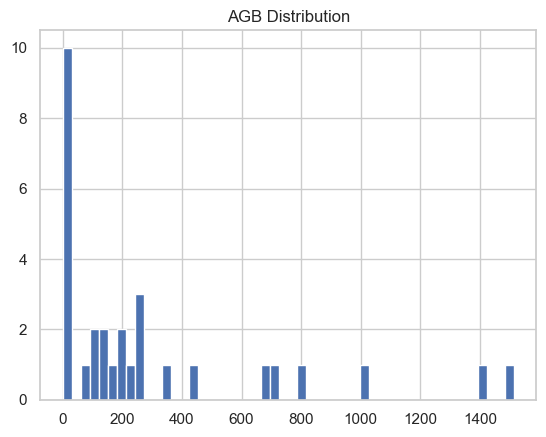

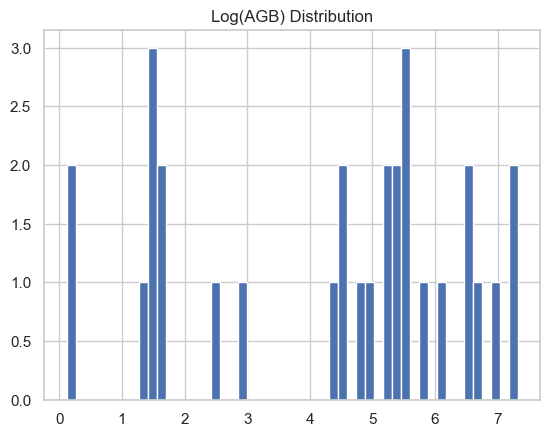

In [31]:
# ============================================================
# 7. Check Target Distribution
# ============================================================

plt.hist(y_raw, bins=50)
plt.title("AGB Distribution")
plt.show()

plt.hist(y_log, bins=50)
plt.title("Log(AGB) Distribution")
plt.show()


In [32]:
# ============================================================
# 8. Train / Test Split
# ============================================================

X_train, X_test, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X,
    y_raw,
    y_log,
    test_size=0.30,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (21, 300)
Test shape: (9, 300)


In [33]:
# ============================================================
# 9. Scale Features
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
# ============================================================
# 10. Evaluation Function
# ============================================================

def evaluate_model(model, X_test_scaled, y_test_log, y_test_raw):
    
    pred_log = model.predict(X_test_scaled).flatten()
    pred_raw = np.expm1(pred_log)

    rmse = np.sqrt(mean_squared_error(y_test_raw, pred_raw))
    mae = mean_absolute_error(y_test_raw, pred_raw)
    r2 = r2_score(y_test_raw, pred_raw)

    rmse_log = np.sqrt(mean_squared_error(y_test_log, pred_log))
    mae_log = mean_absolute_error(y_test_log, pred_log)
    r2_log = r2_score(y_test_log, pred_log)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "RMSE_log": rmse_log,
        "MAE_log": mae_log,
        "R2_log": r2_log
    }


In [35]:
# ============================================================
# 11. Model Builder
# ============================================================

def build_model(input_dim, hidden_layers, dropout_rate=0.0, l2_lambda=0.0):
    
    model = Sequential()

    model.add(Dense(
        hidden_layers[0],
        activation="relu",
        input_shape=(input_dim,),
        kernel_regularizer=l2(l2_lambda)
    ))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for units in hidden_layers[1:]:
        model.add(Dense(
            units,
            activation="relu",
            kernel_regularizer=l2(l2_lambda)
        ))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="linear"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


## (c)	Modeling



In [36]:
# ============================================================
# 12. Define Experiments
# ============================================================

experiments = {
    "Model 1": {
        "hidden_layers": [64, 32],
        "dropout_rate": 0.0,
        "l2_lambda": 0.0
    },
    "Model 2": {
        "hidden_layers": [128, 64],
        "dropout_rate": 0.0,
        "l2_lambda": 0.0
    },
    "Model 3": {
        "hidden_layers": [64, 32],
        "dropout_rate": 0.0,
        "l2_lambda": 0.001
    },
    "Model 4": {
        "hidden_layers": [64, 32],
        "dropout_rate": 0.0,
        "l2_lambda": 0.01
    },
    "Model 5": {
        "hidden_layers": [64, 32],
        "dropout_rate": 0.2,
        "l2_lambda": 0.001
    },
    "Model 6": {
        "hidden_layers": [32, 16],
        "dropout_rate": 0.1,
        "l2_lambda": 0.001
    }
}


Training Model 1
Epoch 1/100


C:\ProgramData\anaconda3\envs\csci89s\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 22.5407 - mae: 4.0139 - val_loss: 32.6155 - val_mae: 5.0626
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 15.9158 - mae: 3.3726 - val_loss: 29.2740 - val_mae: 4.7442
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 12.2643 - mae: 2.9581 - val_loss: 25.8725 - val_mae: 4.4488
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 9.5329 - mae: 2.6313 - val_loss: 22.7711 - val_mae: 4.1457
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 7.3739 - mae: 2.3202 - val_loss: 19.6556 - val_mae: 3.8128
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 5.6838 - mae: 2.0212 - val_loss: 16.5387 - val_mae: 3.4673
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 4.3941 - mae: 1.7665 - val_loss: 13.7656 - val_mae: 3.1288
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 3.4349 - mae: 1.5210 - val_loss: 11.6675 - val_mae: 2.8319
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 2.8406 - 

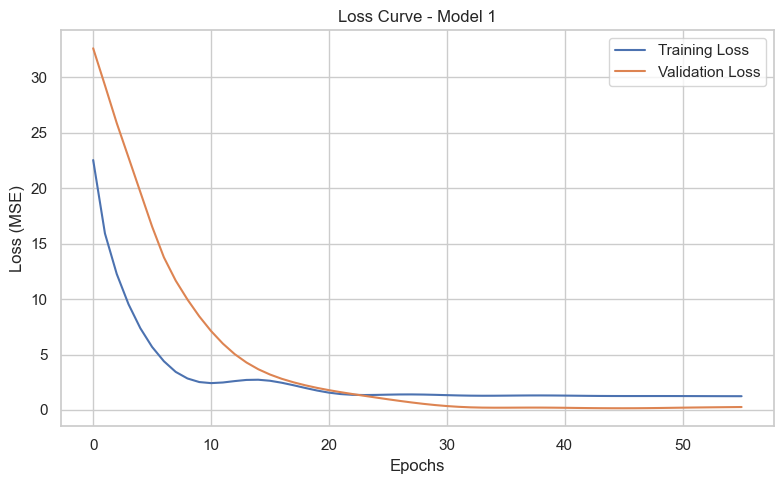

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Model 1 {'RMSE': 238.69425315548852, 'MAE': 125.91359110770047, 'R2': 0.7409193717443039, 'RMSE_log': 0.36022776681567115, 'MAE_log': 0.29513970635969616, 'R2_log': 0.9732676708295371}

Training Model 2
Epoch 1/100


C:\ProgramData\anaconda3\envs\csci89s\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 17.1879 - mae: 3.5018 - val_loss: 28.0812 - val_mae: 4.6449
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 10.3504 - mae: 2.7265 - val_loss: 21.6793 - val_mae: 4.0778
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 6.1750 - mae: 2.0294 - val_loss: 16.2909 - val_mae: 3.5222
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 4.0415 - mae: 1.6264 - val_loss: 11.7932 - val_mae: 2.8653
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 3.2025 - mae: 1.4631 - val_loss: 8.2739 - val_mae: 2.2690
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 2.9698 - mae: 1.3511 - val_loss: 5.7791 - val_mae: 2.0451
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 3.0021 - mae: 1.2917 - val_loss: 4.1136 - val_mae: 1.8114
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 2.9554 - mae: 1.3187 - val_loss: 2.9980 - val_mae: 1.5484
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 2.6733 - mae: 

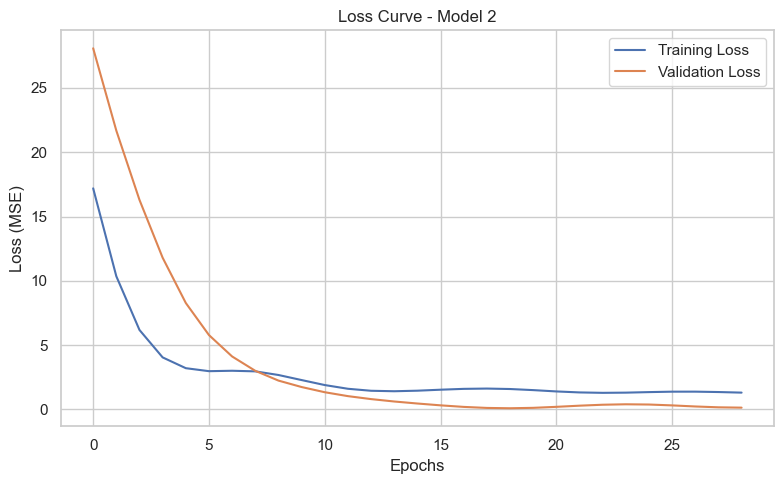

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Model 2 {'RMSE': 252.81757716157884, 'MAE': 175.63754419758948, 'R2': 0.7093532001182732, 'RMSE_log': 0.6362918353440564, 'MAE_log': 0.49927019027772107, 'R2_log': 0.9165944155696215}

Training Model 3
Epoch 1/100


C:\ProgramData\anaconda3\envs\csci89s\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 25.9360 - mae: 4.4383 - val_loss: 41.4384 - val_mae: 5.8547
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 19.2520 - mae: 3.8086 - val_loss: 37.9895 - val_mae: 5.4603
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 15.0336 - mae: 3.3258 - val_loss: 34.7187 - val_mae: 5.1853
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 11.7852 - mae: 2.9195 - val_loss: 31.6000 - val_mae: 4.9906
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 9.4442 - mae: 2.6195 - val_loss: 28.9630 - val_mae: 4.7770
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 7.7468 - mae: 2.3213 - val_loss: 26.2987 - val_mae: 4.5115
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 6.4778 - mae: 2.0112 - val_loss: 24.0028 - val_mae: 4.2426
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 5.5735 - mae: 1.7619 - val_loss: 21.9062 - val_mae: 3.9636
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 4.9763 -

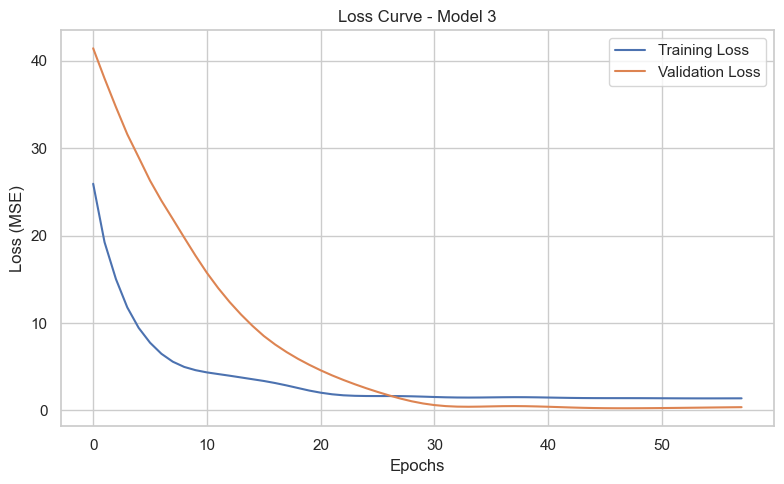

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Model 3 {'RMSE': 194.81738642712423, 'MAE': 108.75830604341076, 'R2': 0.8274136511614556, 'RMSE_log': 0.31928846041479625, 'MAE_log': 0.2772063434666941, 'R2_log': 0.9789985696578534}

Training Model 4
Epoch 1/100


C:\ProgramData\anaconda3\envs\csci89s\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 21.5808 - mae: 4.0083 - val_loss: 36.6790 - val_mae: 5.3391
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 17.6125 - mae: 3.4484 - val_loss: 33.0407 - val_mae: 5.0314
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 14.7524 - mae: 3.1162 - val_loss: 29.6637 - val_mae: 4.8221
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 12.5733 - mae: 2.8898 - val_loss: 26.8517 - val_mae: 4.5754
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 10.7005 - mae: 2.6255 - val_loss: 24.3658 - val_mae: 4.3102
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 9.1708 - mae: 2.3560 - val_loss: 21.9479 - val_mae: 4.0272
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 7.9197 - mae: 2.0935 - val_loss: 19.7557 - val_mae: 3.7251
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 6.8718 - mae: 1.8364 - val_loss: 17.6488 - val_mae: 3.5235
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 5.9891 

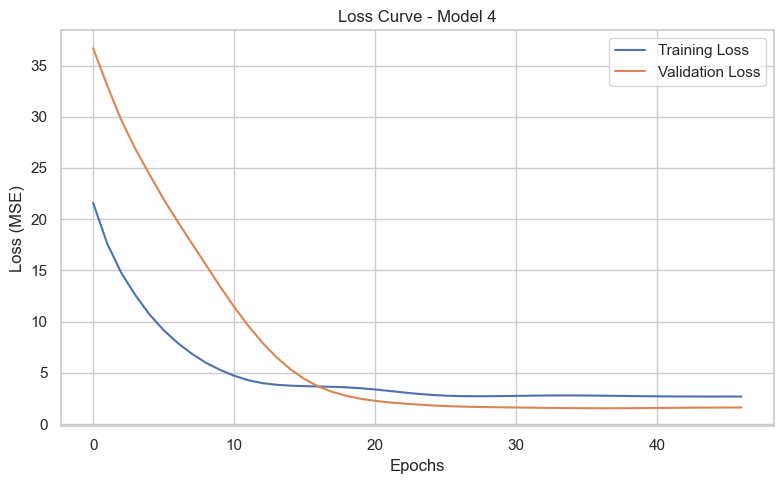

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Model 4 {'RMSE': 205.6901724638661, 'MAE': 108.64475407497262, 'R2': 0.8076119467035772, 'RMSE_log': 0.3517143761930615, 'MAE_log': 0.29742338837843857, 'R2_log': 0.9745162891157161}

Training Model 5
Epoch 1/100


C:\ProgramData\anaconda3\envs\csci89s\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 28.0345 - mae: 4.7405 - val_loss: 32.9306 - val_mae: 5.5120
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 17.9031 - mae: 3.8269 - val_loss: 30.1899 - val_mae: 5.0663
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 18.4218 - mae: 3.8009 - val_loss: 28.5754 - val_mae: 4.6674
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 15.6437 - mae: 3.3867 - val_loss: 26.9140 - val_mae: 4.6300
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 13.4026 - mae: 3.1537 - val_loss: 25.0901 - val_mae: 4.5423
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 14.6483 - mae: 3.4028 - val_loss: 23.4347 - val_mae: 4.4160
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 13.3242 - mae: 3.0013 - val_loss: 21.9753 - val_mae: 4.2873
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 9.9273 - mae: 2.6762 - val_loss: 20.5354 - val_mae: 4.1248
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 9.021

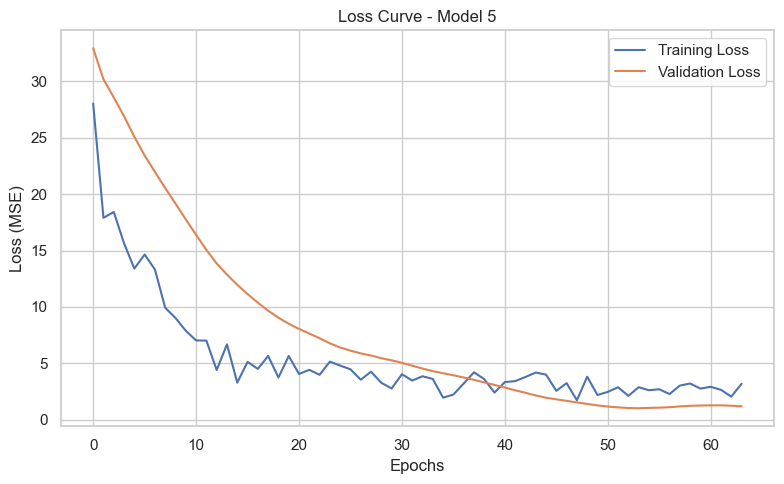

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Model 5 {'RMSE': 440.9984815391802, 'MAE': 245.1566184026443, 'R2': 0.11564791567499133, 'RMSE_log': 0.7718831649686925, 'MAE_log': 0.5498343902693511, 'R2_log': 0.8772601561160256}

Training Model 6
Epoch 1/100


C:\ProgramData\anaconda3\envs\csci89s\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 27.0541 - mae: 4.5425 - val_loss: 40.8310 - val_mae: 5.9363
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 23.7576 - mae: 4.0952 - val_loss: 39.6844 - val_mae: 5.7369
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 19.7022 - mae: 3.8880 - val_loss: 38.4723 - val_mae: 5.5390
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 18.0844 - mae: 3.6776 - val_loss: 37.0644 - val_mae: 5.3444
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 18.1232 - mae: 3.6607 - val_loss: 35.1130 - val_mae: 5.1457
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 15.0607 - mae: 3.2704 - val_loss: 32.8355 - val_mae: 5.0258
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 15.8068 - mae: 3.5125 - val_loss: 31.0035 - val_mae: 4.9329
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 12.5538 - mae: 3.0127 - val_loss: 29.5182 - val_mae: 4.8310
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 9.45

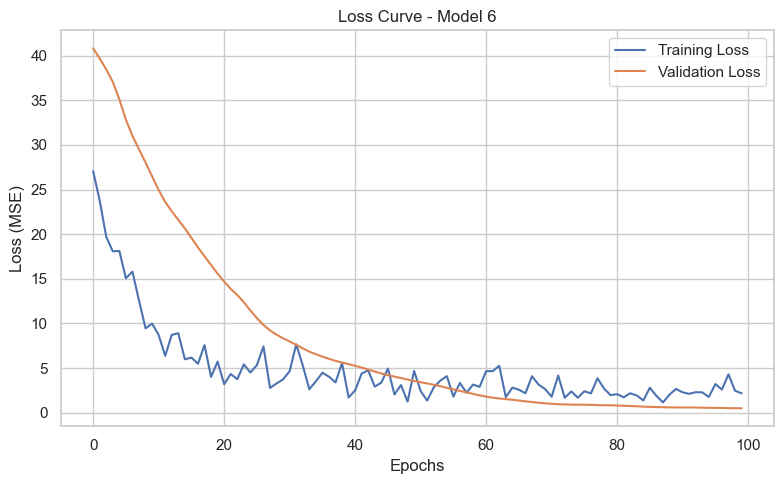

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Model 6 {'RMSE': 372.5728890826855, 'MAE': 202.9973310649999, 'R2': 0.3687905174467758, 'RMSE_log': 0.5822272244620037, 'MAE_log': 0.44681780938047727, 'R2_log': 0.930165915131874}


In [44]:
# ============================================================
# 13. Train Models + Plot Loss Curves
# ============================================================

import matplotlib.pyplot as plt

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

results = {}
models = {}
histories = {}

for name, params in experiments.items():

    print(f"\nTraining {name}")

    model = build_model(
        input_dim=X_train_scaled.shape[1],
        hidden_layers=params["hidden_layers"],
        dropout_rate=params["dropout_rate"],
        l2_lambda=params["l2_lambda"]
    )

    history = model.fit(
        X_train_scaled,
        y_train_log,
        validation_split=0.20,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # ========================================================
    # Plot Loss Curve
    # ========================================================
    history_dict = history.history

    plt.figure(figsize=(8,5))
    plt.plot(history_dict["loss"], label="Training Loss")
    plt.plot(history_dict["val_loss"], label="Validation Loss")
    plt.title(f"Loss Curve - {name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # ========================================================
    # Evaluate Model
    # ========================================================
    metrics = evaluate_model(
        model,
        X_test_scaled,
        y_test_log,
        y_test_raw
    )

    results[name] = metrics
    models[name] = model
    histories[name] = history

    print(name, metrics)

In [45]:
# ============================================================
# 14. Results Table
# ============================================================

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("RMSE")

print(results_df)

               RMSE         MAE        R2  RMSE_log   MAE_log    R2_log
Model 3  194.817386  108.758306  0.827414  0.319288  0.277206  0.978999
Model 4  205.690172  108.644754  0.807612  0.351714  0.297423  0.974516
Model 1  238.694253  125.913591  0.740919  0.360228  0.295140  0.973268
Model 2  252.817577  175.637544  0.709353  0.636292  0.499270  0.916594
Model 6  372.572889  202.997331  0.368791  0.582227  0.446818  0.930166
Model 5  440.998482  245.156618  0.115648  0.771883  0.549834  0.877260


In [46]:
# ============================================================
# 15. Select Best Model
# ============================================================

best_model_name = results_df.index[0]
best_model = models[best_model_name]

print("Best model:", best_model_name)
print(results_df.loc[best_model_name])

Best model: Model 3
RMSE        194.817386
MAE         108.758306
R2            0.827414
RMSE_log      0.319288
MAE_log       0.277206
R2_log        0.978999
Name: Model 3, dtype: float64


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


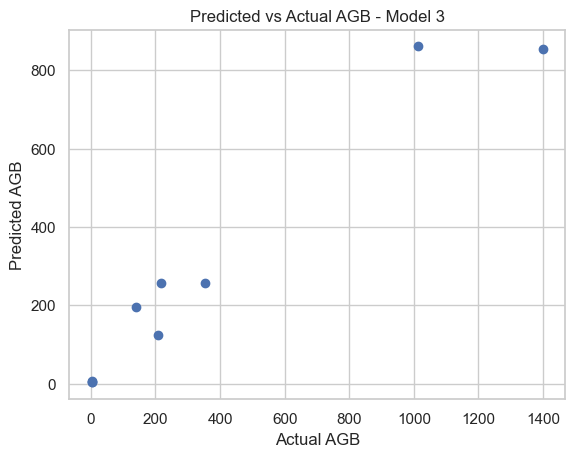

In [47]:
# ============================================================
# 16. Predicted vs Actual Plot
# ============================================================

pred_log = best_model.predict(X_test_scaled).flatten()
pred_raw = np.expm1(pred_log)

plt.scatter(y_test_raw, pred_raw)
plt.xlabel("Actual AGB")
plt.ylabel("Predicted AGB")
plt.title(f"Predicted vs Actual AGB - {best_model_name}")
plt.show()

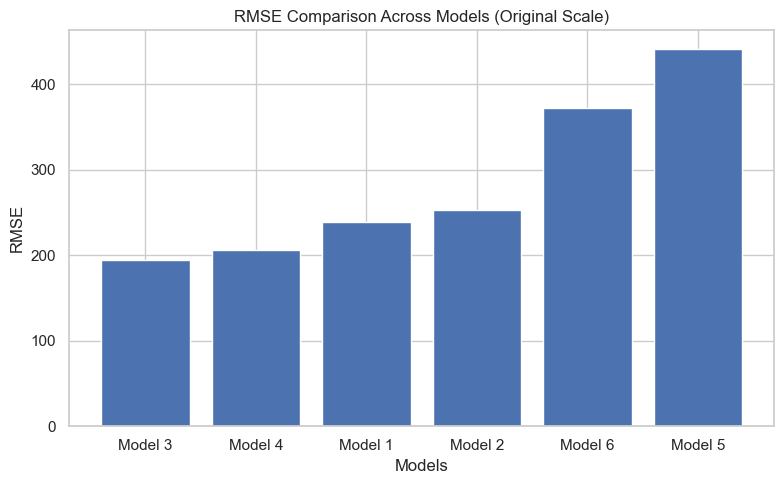

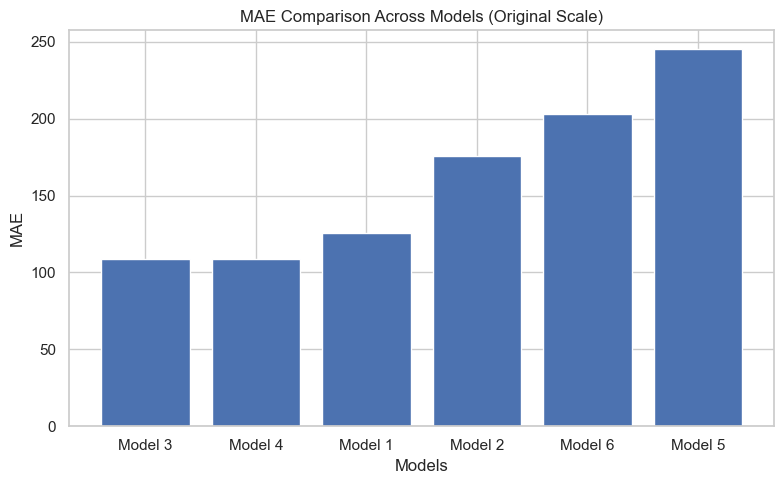

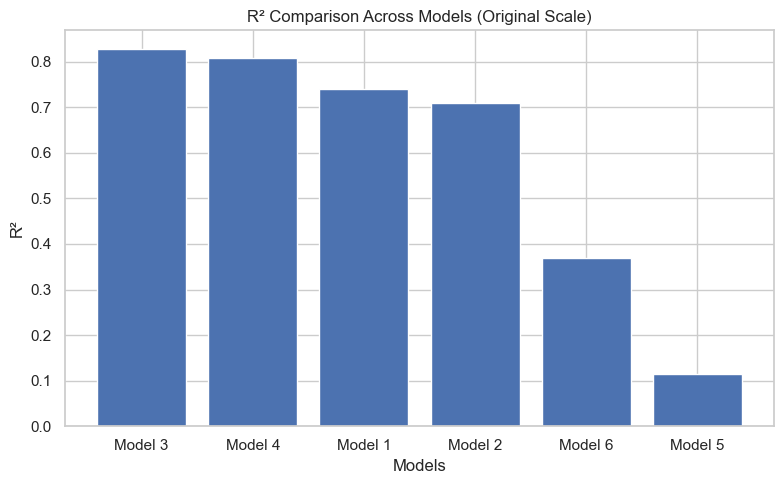

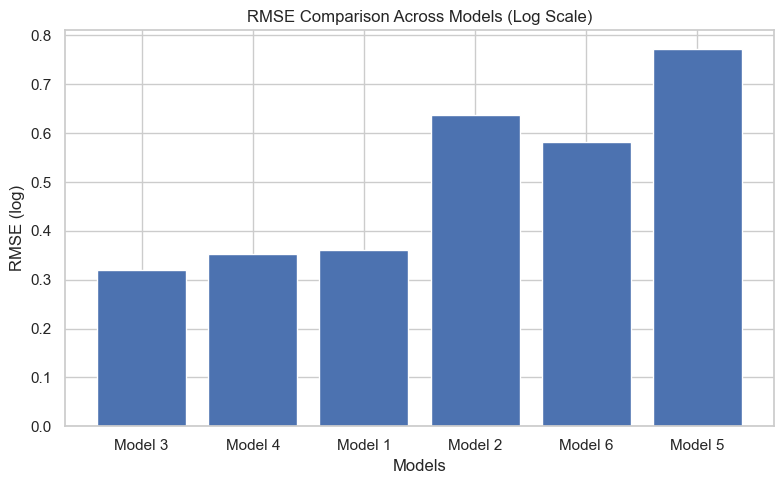

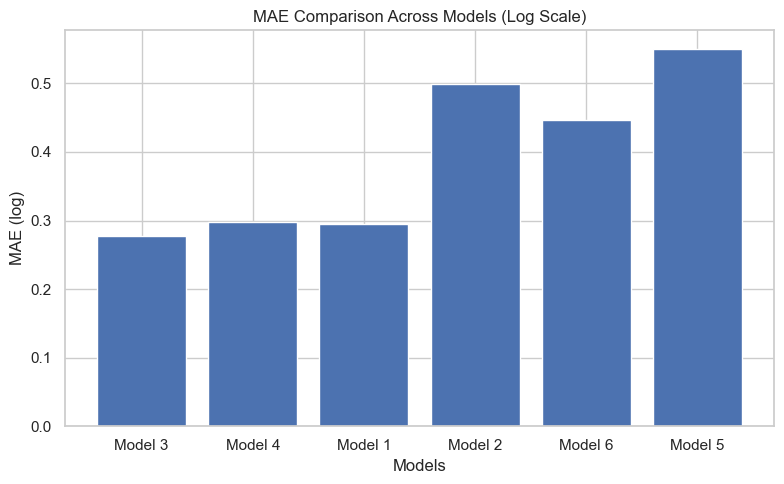

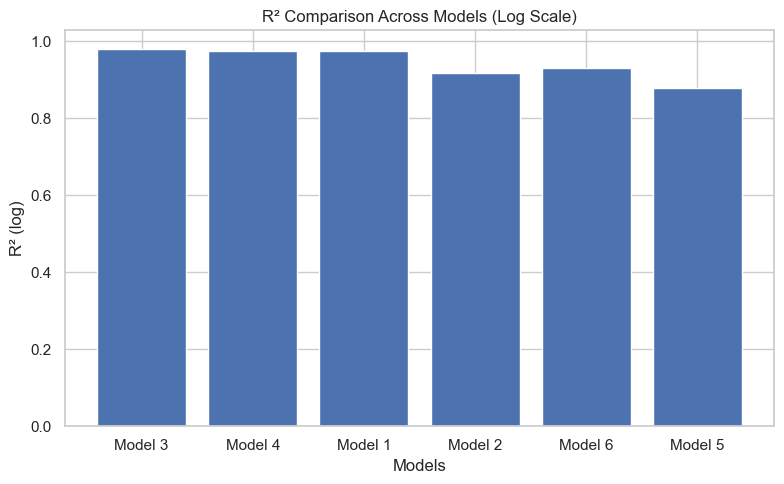

In [48]:
import matplotlib.pyplot as plt

models = results_df.index.tolist()

# Extract metrics
rmse = results_df["RMSE"].values
mae  = results_df["MAE"].values
r2   = results_df["R2"].values

rmse_log = results_df["RMSE_log"].values
mae_log  = results_df["MAE_log"].values
r2_log   = results_df["R2_log"].values


# ============================================================
# RMSE (Original Scale)
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(models, rmse)
plt.title("RMSE Comparison Across Models (Original Scale)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# MAE (Original Scale)
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(models, mae)
plt.title("MAE Comparison Across Models (Original Scale)")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# R² (Original Scale)
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(models, r2)
plt.title("R² Comparison Across Models (Original Scale)")
plt.xlabel("Models")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# RMSE (Log Scale)
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(models, rmse_log)
plt.title("RMSE Comparison Across Models (Log Scale)")
plt.xlabel("Models")
plt.ylabel("RMSE (log)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# MAE (Log Scale)
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(models, mae_log)
plt.title("MAE Comparison Across Models (Log Scale)")
plt.xlabel("Models")
plt.ylabel("MAE (log)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# R² (Log Scale)
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(models, r2_log)
plt.title("R² Comparison Across Models (Log Scale)")
plt.xlabel("Models")
plt.ylabel("R² (log)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

| Model | What Changed | RMSE | MAE | R² | RMSE_log | MAE_log | R²_log | Highlight |
|------|-------------|------|-----|-----|----------|---------|--------|----------|
| Model 1 | Baseline ([64, 32], no regularization) | 238.69 | 125.91 | 0.74 | 0.36 | 0.30 | 0.97 | Moderate performance; limited capacity |
| Model 2 | Deeper network ([128, 64], no regularization) | 252.82 | 175.64 | 0.71 | 0.64 | 0.50 | 0.92 | Unstable performance; possible overfitting or poor convergence |
| Model 3 | L2 regularization (λ = 0.001) | 194.82 | 108.76 | 0.83 | 0.32 | 0.28 | 0.98 | Best overall performance; balanced fit |
| Model 4 | Stronger L2 (λ = 0.01) | 205.69 | 108.64 | 0.81 | 0.35 | 0.30 | 0.97 | Slightly worse than Model 3; mild over-regularization |
| Model 5 | L2 + Dropout (0.2) | 441.00 | 245.16 | 0.12 | 0.77 | 0.55 | 0.88 | Severe underfitting; too much regularization |
| Model 6 | Smaller model ([32, 16] + dropout) | 372.57 | 203.00 | 0.37 | 0.58 | 0.45 | 0.93 | Underfitting due to low capacity |

- Model 3 is the best-performing model, achieving the lowest RMSE providing the best balance between relative and absolute prediction accuracy

- Moderate L2 regularization improves generalization, indicating that some regularization is beneficial for high-dimensional hyperspectral data

- Stronger regularization (Model 4) slightly reduces performance, suggesting over-regularization begins to limit model flexibility

- The deeper unregularized model (Model 2) performs worse than the baseline, indicating instability or overfitting in higher-capacity networks without constraints

- Models with dropout (Model 5 and Model 6) show significant performance degradation, indicating underfitting due to excessive regularization and/or insufficient model capacity

- Baseline model (Model 1) performs reasonably but lacks the capacity to fully capture relationships

